In [49]:
## KNN for classification

## Import necessary libraries
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold,cross_val_score


In [2]:
## Import dataset

In [6]:
wine_data = load_wine()

wine_data_df = pd.DataFrame(data = wine_data.data,columns=wine_data.feature_names)

wine_data_df["Target"] = wine_data.target

In [7]:
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [8]:
## Data understanding

In [10]:
wine_data_df.shape

(178, 14)

In [11]:
wine_data_df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
Target                            int64
dtype: object

In [12]:
wine_data_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

In [13]:
## model building

In [14]:
X = wine_data_df.drop("Target",axis=1)
y = wine_data_df["Target"]

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,shuffle=True,stratify=y,random_state=101)

In [16]:
X_train.shape,y_train.shape

((142, 13), (142,))

In [18]:
X_test.shape,y_test.shape

((36, 13), (36,))

In [19]:
## Model training

In [21]:
KNN_model = KNeighborsClassifier(n_neighbors=3)
KNN_model.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
y_pred_train = KNN_model.predict(X_train)

In [25]:
print("Training Accuracy\n",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy
 0.8873


In [26]:
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
y_pred_train = KNN_model.predict(X_train)

In [28]:
print("Training Accuracy\n",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy
 0.8099


In [30]:
KNN_model = KNeighborsClassifier(n_neighbors=7)
KNN_model.fit(X_train,y_train)
y_pred_train = KNN_model.predict(X_train)
print("Training Accuracy\n",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy
 0.7676


In [31]:
## distance based metric

In [33]:
## must do standard scaler, or normalization

In [34]:
## Let's apply standardization

In [36]:
std_scaler = StandardScaler()
scaled_X = std_scaler.fit_transform(X)

In [37]:
X_train,X_test,y_train,y_test = train_test_split(scaled_X,y,test_size=0.20,shuffle=True,stratify=y,random_state=101)

In [38]:
KNN_model = KNeighborsClassifier(n_neighbors=3)
KNN_model.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
y_pred_train = KNN_model.predict(X_train)

In [40]:
print("Training Accuracy\n",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy
 0.9718


In [41]:
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
y_pred_train = KNN_model.predict(X_train)

In [43]:
print("Training Accuracy\n",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy
 0.9789


In [44]:
KNN_model = KNeighborsClassifier(n_neighbors=7)
KNN_model.fit(X_train,y_train)
y_pred_train = KNN_model.predict(X_train)
print("Training Accuracy\n",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy
 0.9789


## How to choose the optimal no.of neighbours??

In [47]:
#step-1 for loop 3-51 neighbours
# step-2 KNN(n_neighbour = i)
#step-3 cross validation 
# step-4 Cal mean
# step-5 Store it in a list

In [53]:
kfold = KFold(n_splits=5,shuffle=True,random_state=101)
cv_scores_mean = []

for i in range(3,52,2):
    knn_classifier=KNeighborsClassifier(n_neighbors=i)
    knn_classifier.fit(scaled_X,y)
    cv_scores = cross_val_score(estimator=knn_classifier,X=scaled_X,y=y,cv=kfold)
    cv_scores_mean.append(cv_scores.mean().round(4))

In [56]:
cv_scores_mean

[np.float64(0.9663),
 np.float64(0.9716),
 np.float64(0.9773),
 np.float64(0.9717),
 np.float64(0.9662),
 np.float64(0.9662),
 np.float64(0.9773),
 np.float64(0.9662),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9717),
 np.float64(0.9773),
 np.float64(0.9773),
 np.float64(0.9717),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9606),
 np.float64(0.9605)]

In [58]:
max(cv_scores_mean)

np.float64(0.9773)

In [59]:
cv_scores_mean.index(max(cv_scores_mean))

2

In [60]:
## Lets visualize this

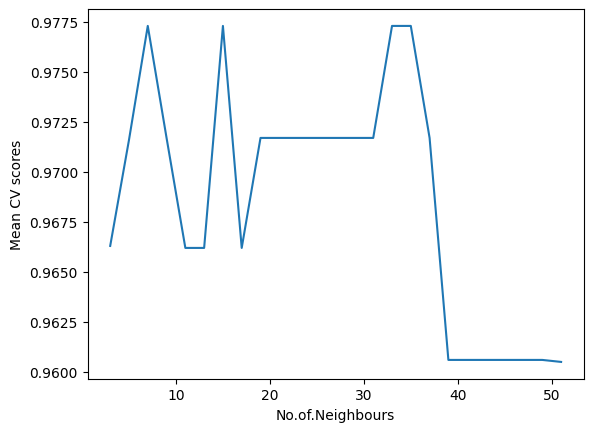

In [62]:
from matplotlib import pyplot as plt
plt.plot(range(3,52,2),cv_scores_mean)
plt.xlabel("No.of.Neighbours")
plt.ylabel("Mean CV scores")
plt.show()